# 02 Inference And Export Features

This notebook loads a finished run, visualizes predictions, and exports per-RoI embeddings for future symbolic experiments.

Future SOCT hook:
- The exported `roi_features` are the explicit RoI embeddings from the two-layer box head, right before the final classifier and regressor.
- That is the intended attachment point for a later symbolic classifier, but no symbolic module is implemented here.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from neuro.datasets import DeepPCBDataset
from neuro.feature_export import export_dataset_roi_features
from neuro.inference import load_checkpoint_model, run_inference, visualize_prediction
from neuro.transforms import build_eval_transforms
from neuro.config import load_yaml
from util.artifacts import latest_run_checkpoint

PROJECT_ROOT = Path.cwd().resolve()


In [2]:
model_config = load_yaml(PROJECT_ROOT / "configs/model.yaml")
train_config = load_yaml(PROJECT_ROOT / "configs/train_deeppcb.yaml")
train_config["dataset"]["root"] = str(PROJECT_ROOT / train_config["dataset"]["root"])
train_config["artifacts"]["checkpoint_dir"] = str(PROJECT_ROOT / train_config["artifacts"]["checkpoint_dir"])
train_config["artifacts"]["feature_export_dir"] = str(PROJECT_ROOT / train_config["artifacts"]["feature_export_dir"])
class_names = tuple(model_config["model"]["class_names"])

checkpoint_path = latest_run_checkpoint(train_config["artifacts"]["checkpoint_dir"])
model, checkpoint = load_checkpoint_model(checkpoint_path, PROJECT_ROOT / "configs/model.yaml", device=train_config.get("device"))
checkpoint_path, checkpoint.get("metrics", {})


(PosixPath('/home/wiszel/Documents/S1/Semester 8/pcb_skripsi/checkpoints/run3.pt'),
 {'mAP@0.5:0.95': 0.7609032392501831,
  'mAP@0.5': 0.9801862239837646,
  'AP75': 0.9172776937484741,
  'AP@50:5:85': 0.9025804996490479,
  'precision': 0.9097900029577048,
  'recall': 0.9796178343949045,
  'mar_100': 0.8474597334861755,
  'precision_recall_score_threshold': 0.5,
  'per_class_AP': {'open': 0.6869093179702759,
   'short': 0.6485353708267212,
   'mouse_bite': 0.7540234923362732,
   'spur': 0.7302480936050415,
   'pinhole': 0.8825065493583679,
   'spurious_copper': 0.863196611404419}})

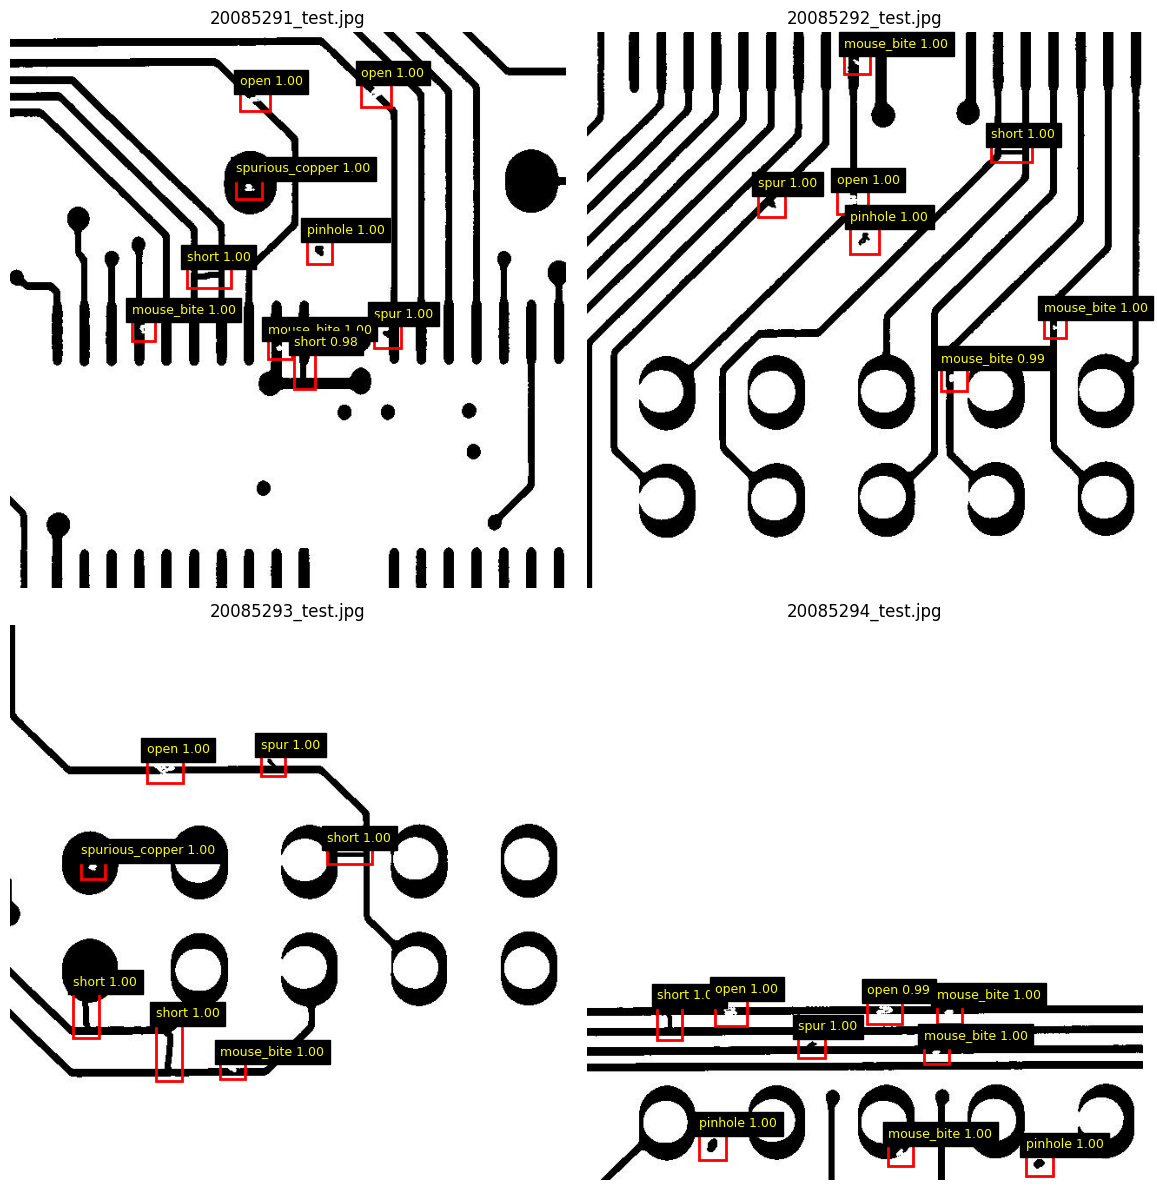

In [3]:
test_dataset = DeepPCBDataset(
    dataset_root=train_config["dataset"]["root"],
    split_file=train_config["dataset"]["test_split"],
    transforms=build_eval_transforms(),
    class_names=class_names,
)

example_indices = [0, 1, 2, 3]
images = [test_dataset[index][0] for index in example_indices]
predictions = run_inference(model, images, device=train_config.get("device", "cpu"))

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for axis, dataset_index, image, prediction in zip(axes.flat, example_indices, images, predictions):
    visualize_prediction(image, prediction, class_names=class_names, score_threshold=0.3, ax=axis)
    axis.set_title(test_dataset.samples[dataset_index].image_path.name)
plt.tight_layout()


In [4]:
run_name = checkpoint_path.stem
feature_export_dir = Path(train_config["artifacts"]["feature_export_dir"])
detections_export_path = feature_export_dir / f"{run_name}_test_detections.pt"
targets_export_path = feature_export_dir / f"{run_name}_test_targets.pt"

export_dataset_roi_features(
    model=model,
    dataset=test_dataset,
    output_path=detections_export_path,
    device=train_config.get("device"),
    proposal_source="detections",
)

export_dataset_roi_features(
    model=model,
    dataset=test_dataset,
    output_path=targets_export_path,
    device=train_config.get("device"),
    proposal_source="targets",
)

detections_export_path, targets_export_path


(PosixPath('/home/wiszel/Documents/S1/Semester 8/pcb_skripsi/checkpoints/feature_exports/run3_test_detections.pt'),
 PosixPath('/home/wiszel/Documents/S1/Semester 8/pcb_skripsi/checkpoints/feature_exports/run3_test_targets.pt'))

## Notes For Future Symbolic Work

- `proposal_source="detections"` exports embeddings for the detector's final predicted RoIs.
- `proposal_source="targets"` exports embeddings aligned to the labeled defect boxes, which is often cleaner for downstream symbolic supervision.
- A future SOCT head can replace or sit alongside the current classifier/regressor by consuming these RoI embeddings.
